# Regression: June model selection and frozen July–August checks

Predict calendar days from the promised delivery date (negative = early; positive = late), with delivery lead time capped at 45 days.

1. Build June's eligible 365-day historical window.
2. Compare default and CV-tuned models on an identical buffered development holdout.
3. Refit every candidate on that full historical window and compare pooled predictions for June orders.
4. Select the candidate with the lowest June MAE, excluding reference baselines.
5. Explain that fitted model and apply it unchanged to July and August orders.

June is a model-selection sample, not an untouched final test. July and August measure the stability of the frozen model. Complete June outcomes are fully mature by 15 August, so selecting on the whole June cohort and scoring July is a retrospective frozen-model experiment, not a claim that this decision was available on 1 July.


# Environment Set-up

In [1]:
import json, os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('.') if os.path.isdir('src') else os.path.abspath('phase2'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from joblib import Parallel, delayed

from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

from src import RANDOM_STATE, LOOKBACK, PXD
from src.data import load_olist_data
from src.features import (build_feature_table, add_extra_features,
                          NUM_COLS, CAT_COLS, EXTRA_NUM_COLS, LEAKAGE_COLS)
from src.preprocessing import make_preprocessor
from src.labels import (get_required_dates, labels_as_of, regression_targets_as_of,
                        attach_regression_actuals)
from src.splits import chronological_split, day_blocked_time_series_folds, available_outcome_folds, available_training_rows
from src.evaluation import regression_metrics, classification_metrics
from src import report_figures as figs

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
np.random.seed(RANDOM_STATE)

# Constants

In [2]:
RUN_DATE = '2018-06-02'   # June development run
WAITING_PERIOD = LOOKBACK        # Longest wait for a delivery inside the target, chosen in the waiting-period audit below
TEST_DAYS = 30            # Newest historical approval days held out for development selection
N_CV_FOLDS = 5
# Random-search iterations per model; kept small for laptop run times
N_ITER = {'Ridge': 12, 'Decision Tree': 15, 'Random Forest': 6, 'LightGBM': 10}
FIGURE_DIR = 'results/figures'  # Report figures are saved here as PNGs
EXCLUDED_STATUSES = ['canceled', 'unavailable']  # Never delivered: no delivery outcome

REG_NUM_COLS = NUM_COLS + EXTRA_NUM_COLS
REG_FEATURE_COLS = REG_NUM_COLS + CAT_COLS
assert not set(REG_FEATURE_COLS) & set(LEAKAGE_COLS), 'Outcome columns used as features'
PXD = 365  # Historical window, consistent with classification
CV_VALIDATION_DAYS = 30  # Fixed calendar length for every CV validation block


# Load data and create features

In [3]:
olist = load_olist_data()
orders = olist['orders']
final_df = add_extra_features(build_feature_table(olist), olist)
print(f'Shape: {final_df.shape}; unique orders: {final_df["order_id"].nunique():,}')

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols


Loaded reviews: 99,224 rows × 7 cols


Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


Shape: (98959, 61); unique orders: 98,959


# Target definition
**Target:** the number of calendar days between the estimated delivery date shown to the customer and the actual delivery date. Positive is a late delivery, negative is an early one.

$$y = \text{delivery date} - \text{estimated delivery date}$$

**Waiting period.** The model is run at a date *R* and only sees what happened before it. An order approved on day *d* has been observed for just *R − d* days, so a slow order may still be undelivered. We therefore wait at most *W* days after approval for the delivery, and count anything slower as delivered on day *W*:

$$y = \min(\text{lead\_days},\ W) - \text{promised\_lead\_days}$$

- `lead_days` = delivery date − approval date.
- `promised_lead_days` = estimated delivery date − approval date. It is shown to the customer at checkout, so it is known at approval and is also a feature.
- For an order delivered within *W* days of approval, the two formulas agree: *y* is simply delivery date − estimated delivery date.

**Why a waiting period?** A slow order that is still undelivered has no delivery date yet, so it is **right-censored**.
- The v2 classification labels count these orders as late (`late_undelivered`: 1,150 orders at 2018-06-02).
- Dropping them from a regression would remove exactly the worst deliveries and bias predictions downward.

With the waiting period, a still-undelivered order that is already *W* days old is known to have a lead time of at least *W*, so y = W − `promised_lead_days`. Every training order is at least `LOOKBACK` + 1 days old, so with *W* ≤ `LOOKBACK` the target is **fully observed for every valid training order**, using only information before the run date.

**What the waiting period costs.** An order still waiting after *W* days is recorded as at most *W* − `promised_lead_days` days late. When the promise itself is longer than *W* days, such an order is recorded as early although its outcome is not known yet. The audit counts these orders (`capped_before_promise_pct`).

**Population.** Canceled and unavailable orders never get delivered, so they have no delivery outcome; they are excluded. Orders that were shipped but never delivered are kept and capped at *W*.
- Limitation: the dataset only stores each order's final status, so the exclusion uses that snapshot. In training windows (≥ 46 days old) the cancellation would normally already be known.
- At inference time these orders are scored like any other.


## Check waiting-period lengths at each model training date
The table shows, for each candidate waiting period *W* and run date, how many training orders are still waiting at *W* and how many targets are known. This mirrors the buffer audit in the classification notebook.

In [4]:
delivered = final_df['order_delivered_customer_date'].notna()
lead_days = (final_df['order_delivered_customer_date'].dt.normalize() - final_df['order_approved_dt']).dt.days
days_from_promise = lead_days - final_df['promised_lead_days']
display(pd.DataFrame({'lead_days (delivered)': lead_days[delivered],
                      'days_from_promise (delivered)': days_from_promise[delivered]})
        .describe(percentiles=[.05, .25, .5, .75, .9, .95, .99]))

audit_rows = []
for run_date in ['2018-02-01', '2018-04-01', '2018-06-01', '2018-08-01']:
    start, end, _ = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD, verbose=False)
    window = final_df[final_df['order_approved_dt'].between(start, end)
                      & ~final_df['order_status'].isin(EXCLUDED_STATUSES)]
    for waiting_period in [21, 30, 45]:
        targets = regression_targets_as_of(window, run_date=run_date, waiting_period=waiting_period)
        status = targets['target_status'].value_counts(normalize=True) * 100
        capped = targets['target_status'].isin(['capped_delivered', 'capped_undelivered'])
        audit_rows.append({'run_date': run_date, 'waiting_period': waiting_period, 'orders': len(targets),
                           'known_pct': 100 * targets['target_as_of_run'].notna().mean(),
                           'capped_pct': 100 * capped.mean(),
                           'capped_before_promise_pct': 100 * (capped & targets['promised_lead_days'].gt(waiting_period)).mean(),
                           'unresolved_pct': status.get('unresolved', 0)})
waiting_period_audit = pd.DataFrame(audit_rows)
display(waiting_period_audit.round(2))

,lead_days (delivered),days_from_promise (delivered)
count,96190.000,96190.000
mean,11.965,-11.806
std,9.510,10.089
min,-7.000,-147.000
5%,2.000,-26.000
25%,6.000,-17.000
50%,10.000,-12.000
75%,15.000,-7.000
90%,22.000,-2.000
95%,29.000,3.000


,run_date,waiting_period,orders,known_pct,capped_pct,capped_before_promise_pct,unresolved_pct
0,2018-02-01,21,42427,99.980,12.540,10.710,0
1,2018-02-01,30,42427,99.980,5.910,2.180,0
2,2018-02-01,45,42427,99.980,3.040,0.140,0
3,2018-04-01,21,52671,99.980,13.650,11.980,0
4,2018-04-01,30,52671,99.980,6.170,2.410,0
5,2018-04-01,45,52671,99.980,2.920,0.120,0
6,2018-06-01,21,62581,99.980,15.740,13.090,0
7,2018-06-01,30,62581,99.980,7.220,2.380,0
8,2018-06-01,45,62581,99.980,3.110,0.110,0
9,2018-08-01,21,69405,99.980,14.940,12.360,0


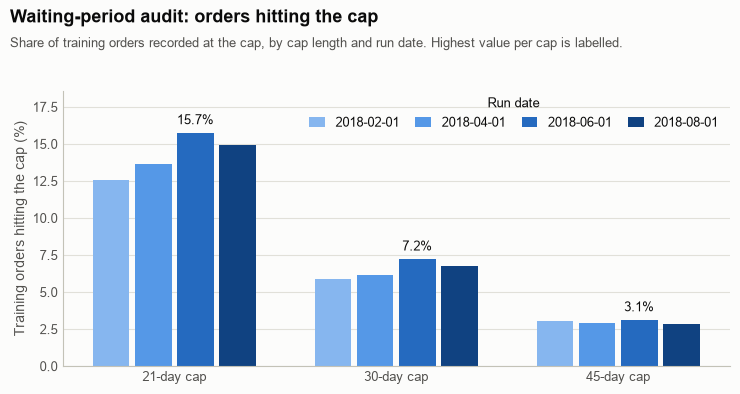

In [5]:
figs.plot_waiting_period_audit(waiting_period_audit, save_path=f'{FIGURE_DIR}/01_waiting_period_audit.png')

**Reading the audit.**
- At *W* = 45, about 1% of *delivered* orders exceed the cap. Counting shipped-but-never-delivered orders too, 2.8–3.1% of training orders are capped. Every valid target is known.
- At *W* = 30, 6–7% of training orders are capped, and at *W* = 21, 13–16%. That loses detail in exactly the long-delay tail the stakeholder cares about.
- Orders capped before their promised date, and so recorded as early, are 0.10–0.14% of training orders at *W* = 45. At *W* = 30 they are 2.2–2.4%, and at *W* = 21, 11–13%.
- **Decision: `WAITING_PERIOD = LOOKBACK = 45`.** One buffer then serves both tasks.

# Get training data

In [6]:
train_test_start_date, train_test_end_date, inference_date = get_required_dates(
    RUN_DATE, lookback=LOOKBACK, pXd=PXD)
window = final_df[final_df['order_approved_dt'].between(train_test_start_date, train_test_end_date)]
excluded = window['order_status'].isin(EXCLUDED_STATUSES)
print(f'Excluded never-delivered orders ({", ".join(EXCLUDED_STATUSES)}): {excluded.sum():,}')

reg_audit = regression_targets_as_of(window[~excluded], run_date=RUN_DATE, waiting_period=WAITING_PERIOD)
display(reg_audit['target_status'].value_counts().to_frame('orders'))
reg_df = reg_audit[reg_audit['target_as_of_run'].notna()].copy()
reg_df['y'] = reg_df['target_as_of_run'].astype(float)
print(f'Training/test orders with a known target: {len(reg_df):,}')

# The classification label for the same orders, for the dual-framing comparison later
reg_df['late_label'] = labels_as_of(reg_df, run_date=RUN_DATE)['label_as_of_run']

Train-test period for the inference date of 2018-06-01 with buffer of 45 days:
    2017-04-18 to 2018-04-17 (365 days)
Excluded never-delivered orders (canceled, unavailable): 753


,orders
target_status,
delivered_within_waiting_period,60886
capped_undelivered,1198
capped_delivered,757
invalid_or_missing_dates,11


Training/test orders with a known target: 62,841


## Training and development holdout split
- **Development holdout:** the latest `TEST_DAYS` (30) approval days of the historical window.
- **Development training:** earlier approvals, excluding the 45 days before the holdout and training outcomes not yet available when the holdout begins.

The development holdout is used to compare default and tuned candidates and record the best development-holdout candidate. The 45-day gap reflects the label waiting period; CV folds use the same gap and availability check. The later June orders form the model-selection cohort.

In [7]:
train_df, test_df = chronological_split(reg_df, date_col='order_approved_dt', test_days=TEST_DAYS, gap_days=WAITING_PERIOD)
train_df = available_training_rows(
    train_df, test_df['order_approved_dt'].min(), 'y',
    lambda rows, date: regression_targets_as_of(rows, date, WAITING_PERIOD), 'target_as_of_run')
train_df = train_df.sort_values('order_approved_dt', kind='stable')
X_train, y_train = train_df[REG_FEATURE_COLS], train_df['y']
X_test, y_test = test_df[REG_FEATURE_COLS], test_df['y']
print(f'Train: {train_df["order_approved_dt"].min():%Y-%m-%d} to {train_df["order_approved_dt"].max():%Y-%m-%d} '
      f'({len(train_df):,} orders, mean y {y_train.mean():.2f})')
print(f'Test:  {test_df["order_approved_dt"].min():%Y-%m-%d} to {test_df["order_approved_dt"].max():%Y-%m-%d} '
      f'({len(test_df):,} orders, mean y {y_test.mean():.2f})')


Train: 2017-04-18 to 2018-02-01 (45,371 orders, mean y -11.44)
Test:  2018-03-19 to 2018-04-17 (6,847 orders, mean y -9.78)


# Preprocessor and models
Two families across the whole project, as the brief's model-family budget requires. Each starts from its simplest variant:

| Family | Baseline | More complex |
|---|---|---|
| Linear | Linear Regression | Ridge |
| Tree-based | Decision Tree | Random Forest, LightGBM |

There are also two reference baselines. They are scored everywhere but are excluded from model selection:
- `DummyRegressor(median)`: the typical number of days an order arrives ahead of its promise.
- **Olist promise**: predict zero, i.e. delivery exactly on the promised date (lead time capped at the waiting period *W*). This is the bar that matters to the business: *does the model estimate delivery better than the date Olist already shows the customer?*

All preprocessing is fitted inside each pipeline, using the same `make_preprocessor` (`src/preprocessing.py`) as the classification pipelines:
- Median imputation, with scaling for the linear models only.
- One-hot encoding of categorical columns.

In [8]:
def make_pipeline(model, scale=False):
    return Pipeline([('preprocessor', make_preprocessor(REG_NUM_COLS, CAT_COLS, scale)), ('model', model)])

def clip_to_waiting_period(predicted, promised_lead_days):
    """Limit predicted days from the promise to a lead time between 0 and WAITING_PERIOD days."""
    promised = np.asarray(promised_lead_days, dtype=float)
    return np.clip(predicted, -promised, WAITING_PERIOD - promised)

class PromiseBaseline(DummyRegressor):
    """Predicts delivery on the promised date: zero days off (lead time capped at WAITING_PERIOD)."""
    def fit(self, X, y, sample_weight=None):
        return super().fit(X, y)
    def predict(self, X):
        return clip_to_waiting_period(np.zeros(len(X)), X['promised_lead_days'])

reference_models = {
    'Dummy (median)': DummyRegressor(strategy='median'),
    'Olist promise': PromiseBaseline(),
}

MODEL_FAMILY = {
    'Linear Regression': 'Linear',
    'Ridge': 'Linear',
    'Decision Tree': 'Tree-based',
    'Random Forest': 'Tree-based',
    'LightGBM': 'Tree-based',
}

# Models use n_jobs=1 so parallelism happens only across CV folds/candidates,
# which avoids oversubscribing CPU cores.
default_models = {
    'Linear Regression': make_pipeline(LinearRegression(), scale=True),
    'Ridge': make_pipeline(Ridge(), scale=True),
    'Decision Tree': make_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    'Random Forest': make_pipeline(RandomForestRegressor(n_estimators=100, max_depth=10,
                                                         random_state=RANDOM_STATE, n_jobs=1)),
    'LightGBM': make_pipeline(LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1)),
}

# Small random-search spaces; widen them once the feature set is frozen.
# Linear Regression has nothing to tune.
SEARCH_SPACES = {
    'Ridge': {'model__alpha': np.logspace(-2, 3, 12)},
    'Decision Tree': {'model__max_depth': [4, 6, 8, 10, 12, None],
                      'model__min_samples_leaf': [1, 20, 50, 100, 200]},
    'Random Forest': {'model__n_estimators': [100, 200],
                      'model__max_depth': [8, 12, 16],
                      'model__min_samples_leaf': [10, 30, 60],
                      'model__max_features': [0.3, 0.5]},
    'LightGBM': {'model__n_estimators': [200, 400, 600],
                 'model__learning_rate': [0.02, 0.05, 0.1],
                 'model__num_leaves': [15, 31, 63],
                 'model__min_child_samples': [20, 50, 100],
                 'model__subsample': [0.7, 1.0], 'model__subsample_freq': [1],
                 'model__colsample_bytree': [0.6, 0.8, 1.0],
                 'model__objective': ['regression', 'regression_l1']},
}

# Time-series cross-validation & Hyperparameter tuning
Same order as the classification notebook:
1. Build the CV folds on the training part.
2. Score the default models with CV, then on the hold-out.
3. Tune with `RandomizedSearchCV` on the same folds, then score every default and tuned model on the hold-out.

## Chronological split and CV folds
- **CV:** five expanding folds, each validating on 30 calendar days.
- Leave a 45-day gap before each validation block and retain only training targets known at that block’s start.
- Keep orders from the same approval day together.

The five validation blocks are counted backwards from the end of the development-training period. For the June run, the 290-day development-training window leaves 95 initial calendar days before the first 45-day gap. As the validation date advances, each fold can use more earlier history once it is outside the 45-day gap. The date window moves with each run date; see the optional monthly comparison below.

In [9]:
# Fixed 30-calendar-day validation blocks, ordered chronologically.
# Each fold has a 45-day gap and outcome-availability check.
cv_folds = day_blocked_time_series_folds(
    train_df['order_approved_dt'], n_splits=N_CV_FOLDS,
    gap_days=WAITING_PERIOD, validation_days=CV_VALIDATION_DAYS)
cv_folds = available_outcome_folds(
    train_df, cv_folds, y_train,
    lambda rows, date: regression_targets_as_of(rows, date, WAITING_PERIOD), 'target_as_of_run')
assert len(cv_folds) == N_CV_FOLDS
print(f'CV: {len(cv_folds)} folds with a {WAITING_PERIOD}-day gap and known training targets')
display(pd.DataFrame([{
            'fold': k, 'train_orders': len(tr), 'valid_orders': len(va),
            'valid_from': train_df['order_approved_dt'].iloc[va].min().date(),
            'valid_to': train_df['order_approved_dt'].iloc[va].max().date(),
            'valid_mean_y': round(y_train.iloc[va].mean(), 2),
                  } for k, (tr, va) in enumerate(cv_folds, 1)]
            ).set_index('fold')
      )

CV: 5 folds with a 45-day gap and known training targets


,train_orders,valid_orders,valid_from,valid_to,valid_mean_y
fold,,,,,
1,10697,4358,2017-09-05,2017-10-04,-11.350
2,14711,4291,2017-10-05,2017-11-03,-11.130
3,18961,7700,2017-11-04,2017-12-03,-7.950
4,23309,5202,2017-12-04,2018-01-02,-12.820
5,27919,7133,2018-01-03,2018-02-01,-12.630


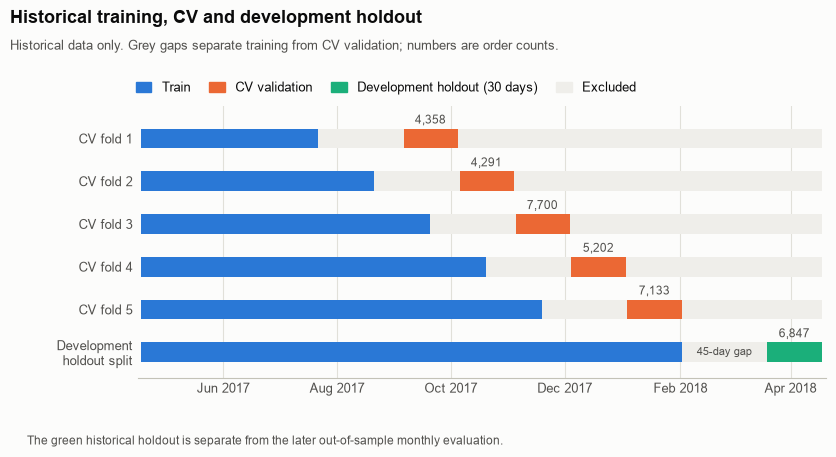

In [10]:
figs.plot_split_and_folds(train_df['order_approved_dt'], test_df['order_approved_dt'], cv_folds,
                          save_path=f'{FIGURE_DIR}/02_split_and_cv_folds.png')

## Cross-validated defaults
### Development-fold metrics
- **MAE** is the primary metric. It reads directly as "days off" in the predicted delivery date.
- RMSE and R² are reported alongside it.

In [11]:
SCORING = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

def cv_summary(model, X, y, folds, n_jobs=-1):
    """Mean and standard deviation of each CV score across the given folds."""
    scores = cross_validate(model, X, y, cv=folds, scoring=SCORING, n_jobs=n_jobs)
    row = {}
    for metric in SCORING:
        values = scores[f'test_{metric}'] * (1 if metric == 'r2' else -1)
        row[f'cv_{metric}_mean'], row[f'cv_{metric}_std'] = values.mean(), values.std()
    return row

cv_rows = []
for name, model in reference_models.items():
    cv_rows.append({'model': name, 'variant': 'reference', 'family': 'Reference',
                    **cv_summary(model, X_train, y_train, cv_folds)})
for name, model in default_models.items():
    cv_rows.append({'model': name, 'variant': 'default', 'family': MODEL_FAMILY[name],
                    **cv_summary(model, X_train, y_train, cv_folds)})
display(pd.DataFrame(cv_rows).set_index(['model', 'variant']))

,,family,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
model,variant,,,,,,,
Dummy (median),reference,Reference,6.441,0.600,9.467,0.841,-0.070,0.099
Olist promise,reference,Reference,12.810,1.163,14.255,1.107,-1.463,0.420
Linear Regression,default,Linear,6.149,1.506,9.417,2.472,-0.084,0.477
Ridge,default,Linear,6.159,1.727,9.389,2.150,-0.066,0.385
Decision Tree,default,Tree-based,8.816,1.265,12.883,1.327,-0.994,0.342
Random Forest,default,Tree-based,5.933,0.918,8.575,0.970,0.124,0.107
LightGBM,default,Tree-based,5.653,0.818,8.381,0.850,0.163,0.080


### How much does a random split flatter the scores?
This scores the same default LightGBM with random 5-fold CV on the same rows. The gap from the time-series CV is the optimism that comes from training on orders that come after some of the validation orders.

In [12]:
random_cv = cv_summary(default_models['LightGBM'], X_train, y_train,
                       KFold(5, shuffle=True, random_state=RANDOM_STATE))
time_cv = next(row for row in cv_rows if row['model'] == 'LightGBM')
display(pd.DataFrame({'random 5-fold': random_cv, 'time-series 5-fold': time_cv})
        .loc[['cv_mae_mean', 'cv_rmse_mean', 'cv_r2_mean']].astype(float))

,random 5-fold,time-series 5-fold
cv_mae_mean,5.154,5.653
cv_rmse_mean,7.712,8.381
cv_r2_mean,0.291,0.163


### Development holdout metrics
Reference baselines and default models are fitted on the development-training rows and scored once on the development holdout. The tuned models are added after the random search.

In [13]:
holdout_metrics, test_predictions, fitted_models = {}, {}, {}

def score_holdout(key, model):
    """Fit on the training part and score the hold-out; predictions are clipped to the waiting period."""
    fitted_models[key] = clone(model).fit(X_train, y_train)
    test_predictions[key] = clip_to_waiting_period(fitted_models[key].predict(X_test), X_test['promised_lead_days'])
    holdout_metrics[key] = regression_metrics(y_test, test_predictions[key])

for name, model in reference_models.items():
    score_holdout((name, 'reference'), model)
for name, model in default_models.items():
    score_holdout((name, 'default'), model)
display(pd.DataFrame(holdout_metrics).T.rename_axis(['model', 'variant']).sort_values('mae'))


,,mae,rmse,r2,median_ae,bias
model,variant,,,,,
LightGBM,default,5.569,8.279,0.234,3.759,-0.623
Linear Regression,default,5.585,8.341,0.222,3.787,-0.933
Ridge,default,5.602,8.305,0.229,3.856,-0.745
Random Forest,default,5.729,8.433,0.205,3.925,-0.553
Dummy (median),reference,6.733,9.864,-0.088,5.000,-3.022
Decision Tree,default,8.269,12.308,-0.694,5.000,0.323
Olist promise,reference,11.867,13.550,-1.053,11.000,9.745


## Conduct hyperparameter tuning
Random search minimises mean MAE on the five chronological CV folds. Default and tuned candidates use the same development-training and holdout rows. The holdout winner is recorded separately; the eventual frozen model is chosen using pooled June order predictions.

### Random search
Each model searches a small grid (`SEARCH_SPACES` above) on the time-series folds, minimising mean MAE.
- Linear Regression has no hyperparameters, so it has a default variant only.
- The hold-out is not used for tuning.

In [14]:
tuned_models, best_params = {}, {}
for name, space in SEARCH_SPACES.items():
    search = RandomizedSearchCV(default_models[name], space, n_iter=N_ITER[name], cv=cv_folds,
                                scoring='neg_mean_absolute_error', random_state=RANDOM_STATE,
                                n_jobs=-1, refit=False)
    search.fit(X_train, y_train)
    best_params[name] = {key: (value.item() if isinstance(value, np.generic) else value)
                         for key, value in search.best_params_.items()}
    tuned_models[name] = clone(default_models[name]).set_params(**search.best_params_)
    cv_rows.append({'model': name, 'variant': 'tuned', 'family': MODEL_FAMILY[name],
                    **cv_summary(tuned_models[name], X_train, y_train, cv_folds)})
    print(f'{name}: {best_params[name]}')

cv_results = pd.DataFrame(cv_rows).set_index(['model', 'variant']).sort_index()
display(cv_results)
display((cv_results.xs('default', level='variant')['cv_mae_mean']
         - cv_results.xs('tuned', level='variant')['cv_mae_mean'])
        .dropna().rename('cv_mae_reduction_from_tuning').to_frame())

Ridge: {'model__alpha': 1000.0}


Decision Tree: {'model__min_samples_leaf': 100, 'model__max_depth': 6}


Random Forest: {'model__n_estimators': 200, 'model__min_samples_leaf': 60, 'model__max_features': 0.5, 'model__max_depth': 16}


LightGBM: {'model__subsample_freq': 1, 'model__subsample': 0.7, 'model__objective': 'regression_l1', 'model__num_leaves': 63, 'model__n_estimators': 600, 'model__min_child_samples': 50, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.6}


family  cv_mae_mean  cv_mae_std  \
model             variant                                          
Decision Tree     default    Tree-based        8.816       1.265   
                  tuned      Tree-based        5.750       0.797   
Dummy (median)    reference   Reference        6.441       0.600   
LightGBM          default    Tree-based        5.653       0.818   
                  tuned      Tree-based        5.537       0.808   
Linear Regression default        Linear        6.149       1.506   
Olist promise     reference   Reference       12.810       1.163   
Random Forest     default    Tree-based        5.933       0.918   
                  tuned      Tree-based        5.616       0.744   
Ridge             default        Linear        6.159       1.727   
                  tuned          Linear        6.059       1.541   

                             cv_rmse_mean  cv_rmse_std  cv_r2_mean  cv_r2_std  
model             variant                                                      
Decision Tree     default          12.883        1.327      -0.994      0.342  
                  tuned             8.667        0.983       0.105      0.106  
Dummy (median)    reference         9.467        0.841      -0.070      0.099  
LightGBM          default           8.381        0.850       0.163      0.080  
                  tuned             8.662        0.982       0.106      0.109  
Linear Regression default           9.417        2.472      -0.084      0.477  
Olist promise     reference        14.255        1.107      -1.463      0.420  
Random Forest     default           8.575        0.970       0.124      0.107  
                  tuned             8.467        0.879       0.146      0.086  
Ridge             default           9.389        2.150      -0.066      0.385  
                  tuned             9.309        1.935      -0.043      0.333

,cv_mae_reduction_from_tuning
model,
Decision Tree,3.066
LightGBM,0.117
Random Forest,0.317
Ridge,0.100


In [15]:
candidate_models = {**{(name, 'default'): model for name, model in default_models.items()},
                    **{(name, 'tuned'): model for name, model in tuned_models.items()}}

leaderboard = cv_results.loc[list(candidate_models),
                             ['family', 'cv_mae_mean', 'cv_mae_std', 'cv_rmse_mean', 'cv_r2_mean']]
leaderboard = leaderboard.sort_values('cv_mae_mean')
leaderboard['mae_gap_to_best'] = leaderboard['cv_mae_mean'] - leaderboard['cv_mae_mean'].iloc[0]
display(leaderboard)


,,family,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_r2_mean,mae_gap_to_best
model,variant,,,,,,
LightGBM,tuned,Tree-based,5.537,0.808,8.662,0.106,0.000
Random Forest,tuned,Tree-based,5.616,0.744,8.467,0.146,0.079
LightGBM,default,Tree-based,5.653,0.818,8.381,0.163,0.117
Decision Tree,tuned,Tree-based,5.750,0.797,8.667,0.105,0.213
Random Forest,default,Tree-based,5.933,0.918,8.575,0.124,0.397
Ridge,tuned,Linear,6.059,1.541,9.309,-0.043,0.522
Linear Regression,default,Linear,6.149,1.506,9.417,-0.084,0.612
Ridge,default,Linear,6.159,1.727,9.389,-0.066,0.622
Decision Tree,default,Tree-based,8.816,1.265,12.883,-0.994,3.279


### Development holdout evaluation (newest 30 days of the window)

In [16]:
scored_models = {**{(name, 'reference'): model for name, model in reference_models.items()},
                 **candidate_models}
for name, model in tuned_models.items():
    score_holdout((name, 'tuned'), model)
holdout_results = pd.DataFrame(holdout_metrics).T.rename_axis(['model', 'variant']).sort_values('mae')
display(holdout_results)


mae   rmse     r2  median_ae   bias
model             variant                                         
LightGBM          tuned      5.394  8.429  0.206      3.352 -1.786
                  default    5.569  8.279  0.234      3.759 -0.623
Linear Regression default    5.585  8.341  0.222      3.787 -0.933
Ridge             default    5.602  8.305  0.229      3.856 -0.745
                  tuned      5.628  8.324  0.225      3.876 -0.673
Random Forest     tuned      5.669  8.380  0.215      3.903 -0.633
                  default    5.729  8.433  0.205      3.925 -0.553
Decision Tree     tuned      5.883  8.624  0.168      4.040 -0.693
Dummy (median)    reference  6.733  9.864 -0.088      5.000 -3.022
Decision Tree     default    8.269 12.308 -0.694      5.000  0.323
Olist promise     reference 11.867 13.550 -1.053     11.000  9.745

# Development holdout comparison

## Best development-holdout candidate
The lowest holdout MAE identifies the best candidate on this historical sample. This is recorded separately from the model subsequently selected using June orders. Reference baselines are excluded from both selection steps.

In [17]:
holdout_key = min(candidate_models, key=lambda key: holdout_results.loc[key, 'mae'])
holdout_results.insert(0, 'best_on_holdout', [key == holdout_key for key in holdout_results.index])
display(holdout_results)
print(f'Best on development holdout: {holdout_key[0]} ({holdout_key[1]})')


best_on_holdout    mae   rmse     r2  median_ae  \
model             variant                                                      
LightGBM          tuned                 True  5.394  8.429  0.206      3.352   
                  default              False  5.569  8.279  0.234      3.759   
Linear Regression default              False  5.585  8.341  0.222      3.787   
Ridge             default              False  5.602  8.305  0.229      3.856   
                  tuned                False  5.628  8.324  0.225      3.876   
Random Forest     tuned                False  5.669  8.380  0.215      3.903   
                  default              False  5.729  8.433  0.205      3.925   
Decision Tree     tuned                False  5.883  8.624  0.168      4.040   
Dummy (median)    reference            False  6.733  9.864 -0.088      5.000   
Decision Tree     default              False  8.269 12.308 -0.694      5.000   
Olist promise     reference            False 11.867 13.550 -1.053     11.000   

                              bias  
model             variant           
LightGBM          tuned     -1.786  
                  default   -0.623  
Linear Regression default   -0.933  
Ridge             default   -0.745  
                  tuned     -0.673  
Random Forest     tuned     -0.633  
                  default   -0.553  
Decision Tree     tuned     -0.693  
Dummy (median)    reference -3.022  
Decision Tree     default    0.323  
Olist promise     reference  9.745

Best on development holdout: LightGBM (tuned)


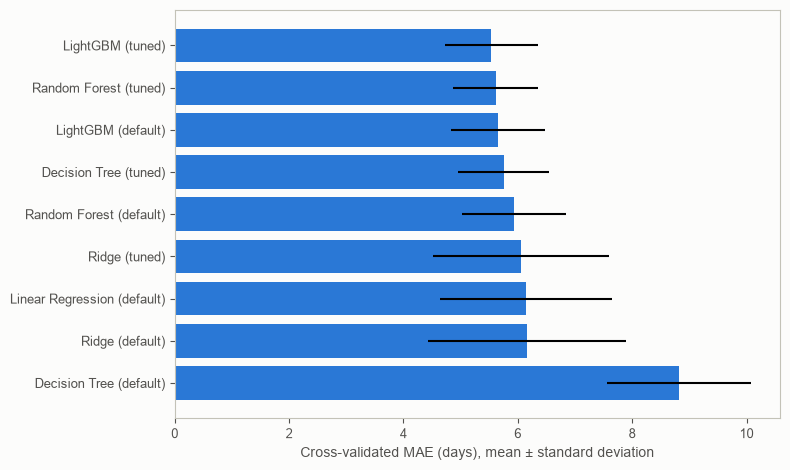

In [18]:
# Display CV performance without implying that CV determines the final selected model.
plot_cv = cv_results.loc[list(candidate_models)].sort_values('cv_mae_mean')
with plt.rc_context(figs.STYLE):
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.barh(range(len(plot_cv)), plot_cv['cv_mae_mean'], xerr=plot_cv['cv_mae_std'], color=figs.BLUE)
    ax.set_yticks(range(len(plot_cv)), [f'{m} ({v})' for m, v in plot_cv.index])
    ax.invert_yaxis()
    ax.set_xlabel('Cross-validated MAE (days), mean ± standard deviation')
    fig.tight_layout()
    fig.savefig(f'{FIGURE_DIR}/03_cv_mae_default_vs_tuned.png', dpi=200)
    plt.show()


## June order comparison and frozen later-month predictions

In [19]:
from pathlib import Path
from src.report_tables import export_report_tables

REPORT_DIR = Path('results/report_tables')
REPORT_DIR.mkdir(parents=True, exist_ok=True)
june_cohort = final_df[final_df['order_approved_dt'].dt.to_period('M').eq(pd.Period('2018-06'))].copy()
observation_end_proxy = orders['order_delivered_customer_date'].max().normalize()


def score_cohort(fitted, cohort):
    """Score without fitting; attach the same 45-day outcome definition to each order."""
    result = cohort[['order_id', 'order_approved_dt']].copy()
    result['predicted'] = clip_to_waiting_period(
        fitted.predict(cohort[REG_FEATURE_COLS]), cohort['promised_lead_days'])
    actuals = attach_regression_actuals(result, orders, waiting_period=WAITING_PERIOD)
    result = result.merge(actuals[['order_id', 'actual_target', 'target_status']], on='order_id')
    result['eligible'] = (result['actual_target'].notna()
                          & (result['order_approved_dt'] + pd.Timedelta(days=WAITING_PERIOD)
                             <= observation_end_proxy))
    return result


# Every candidate is fitted exactly once on the same pre-June historical rows.
full_history_models, prediction_frames, metric_rows = {}, [], []
for key, model in scored_models.items():
    fitted = clone(model).fit(reg_df[REG_FEATURE_COLS], reg_df['y'])
    full_history_models[key] = fitted
    predictions = score_cohort(fitted, june_cohort)
    predictions['model'], predictions['variant'] = key
    prediction_frames.append(predictions)
    known = predictions[predictions['eligible']]
    metric_rows.append({'model': key[0], 'variant': key[1], 'orders': len(known),
                        **regression_metrics(known['actual_target'], known['predicted'])})
june_predictions = pd.concat(prediction_frames, ignore_index=True)
june_metrics = pd.DataFrame(metric_rows).set_index(['model', 'variant'])
june_key = min(candidate_models, key=lambda key: june_metrics.loc[key, 'mae'])
selected_model = full_history_models[june_key]
selected_label = f'{june_key[0]} ({june_key[1]})'
june_metrics['june_selected'] = [key == june_key for key in june_metrics.index]
display(june_metrics.sort_values('mae'))
print(f'June-selected model: {selected_label}')

# Retain the exact fitted pipeline: no fit, CV search, or selection on later months.
frozen_predictions = []
for month in ['2018-06', '2018-07', '2018-08']:
    cohort = final_df[final_df['order_approved_dt'].dt.to_period('M').eq(pd.Period(month))]
    predictions = score_cohort(selected_model, cohort)
    predictions['month'] = month
    frozen_predictions.append(predictions)
frozen_predictions = pd.concat(frozen_predictions, ignore_index=True)
frozen_rows = []
for month, rows in frozen_predictions.groupby('month'):
    known = rows[rows['eligible']]
    frozen_rows.append({'Month': month, 'Scored': len(rows), 'Evaluated': len(known),
                        'MAE (days)': regression_metrics(known['actual_target'], known['predicted'])['mae'],
                        'RMSE (days)': regression_metrics(known['actual_target'], known['predicted'])['rmse'],
                        'R²': regression_metrics(known['actual_target'], known['predicted'])['r2']})
frozen_metrics = pd.DataFrame(frozen_rows)
display(frozen_metrics)

# Explain the June-selected fitted pipeline on the June selection cohort.
selected_june = june_predictions[(june_predictions['model'] == june_key[0])
                                & (june_predictions['variant'] == june_key[1])
                                & june_predictions['eligible']].set_index('order_id')
explanation_rows = june_cohort.set_index('order_id').loc[selected_june.index]
X_explain = explanation_rows[REG_FEATURE_COLS]
y_explain = selected_june['actual_target']


orders    mae   rmse     r2  median_ae   bias  \
model             variant                                                    
LightGBM          tuned        6164  4.846  6.911  0.494      3.882  2.480   
                  default      6164  6.181  7.850  0.347      5.387  4.374   
Random Forest     tuned        6164  6.350  8.018  0.318      5.625  4.532   
Ridge             default      6164  6.544  8.115  0.302      5.711  4.801   
Linear Regression default      6164  6.549  8.120  0.301      5.717  4.805   
Ridge             tuned        6164  6.689  8.242  0.280      5.844  4.965   
Random Forest     default      6164  7.027  8.590  0.218      6.413  5.334   
Decision Tree     tuned        6164  7.547  9.127  0.117      7.092  5.763   
                  default      6164  7.686 11.420 -0.383      5.000  4.583   
Dummy (median)    reference    6164  9.248 11.846 -0.488      8.000  7.010   
Olist promise     reference    6164 19.307 20.895 -3.630     19.000 18.677   

                             june_selected  
model             variant                   
LightGBM          tuned               True  
                  default            False  
Random Forest     tuned              False  
Ridge             default            False  
Linear Regression default            False  
Ridge             tuned              False  
Random Forest     default            False  
Decision Tree     tuned              False  
                  default            False  
Dummy (median)    reference          False  
Olist promise     reference          False

June-selected model: LightGBM (tuned)


,Month,Scored,Evaluated,MAE (days),RMSE (days),R²
0,2018-06,6164,6164,4.846,6.911,0.494
1,2018-07,6176,6159,4.612,7.616,0.314
2,2018-08,6620,6612,4.591,7.471,0.414


## Interpretation of the June-selected fitted model
Permutation importance and residuals use June orders, the same sample used to choose the model. These explanations are descriptive of the selection cohort; July and August provide the subsequent frozen-model checks.

### Permutation importance (June selection cohort, raw features)

In [20]:
perm = permutation_importance(selected_model, X_explain, y_explain, n_repeats=5, random_state=RANDOM_STATE,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
importance = (pd.DataFrame({'feature': REG_FEATURE_COLS,
                            'mae_increase_days': perm.importances_mean,
                            'std': perm.importances_std})
              .sort_values('mae_increase_days', ascending=False).head(20).reset_index(drop=True))
display(importance)

,feature,mae_increase_days,std
0,promised_lead_days,5.272,0.031
1,order_product_weight_g_sum,0.046,0.004
2,order_pdt_price_sum,0.022,0.001
3,order_product_volume_cm3_sum,0.022,0.004
4,order_approved_day_of_week,0.020,0.004
5,orders_approved_prev_7d,0.019,0.003
6,payment_type_value_credit_card,0.016,0.001
7,approval_lag_hours,0.010,0.001
8,order_revenue_sum,0.008,0.001
9,order_approved_week_of_year,0.005,0.001


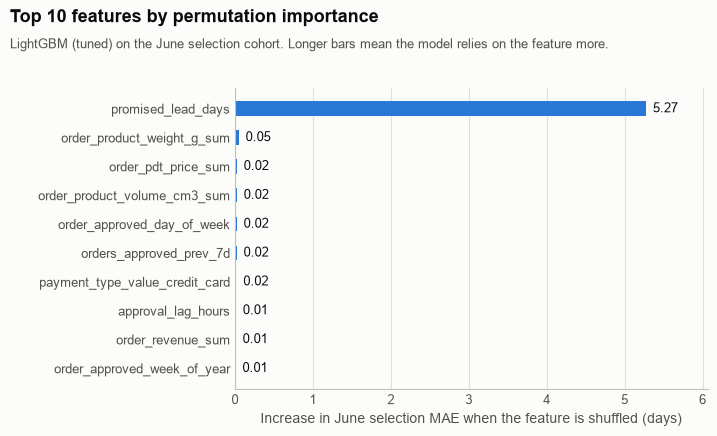

In [21]:
figs.plot_feature_importance(importance.head(10), selected_label,
                             save_path=f'{FIGURE_DIR}/06_feature_importance.png', cohort_label='June selection')

### Residuals by segment

,orders,actual_mean,predicted_mean,bias,mae
route_type,,,,,
1. All interstate,3768,-21.759,-18.249,3.511,5.829
2. All same-state,2378,-14.372,-13.522,0.850,3.307
3. Mixed,18,-25.500,-23.480,2.020,2.249


,orders,actual_mean,predicted_mean,bias,mae
customer_state,,,,,
SP,2765,-15.862,-14.730,1.132,3.572
MG,720,-20.633,-17.087,3.546,4.504
RJ,711,-25.677,-21.623,4.053,6.896
PR,309,-20.673,-17.565,3.108,4.259
RS,305,-23.125,-19.393,3.731,5.589
SC,205,-21.151,-16.487,4.664,5.215
BA,201,-15.861,-14.833,1.028,7.869
DF,152,-19.125,-15.216,3.909,5.880
ES,126,-16.175,-14.276,1.899,4.994


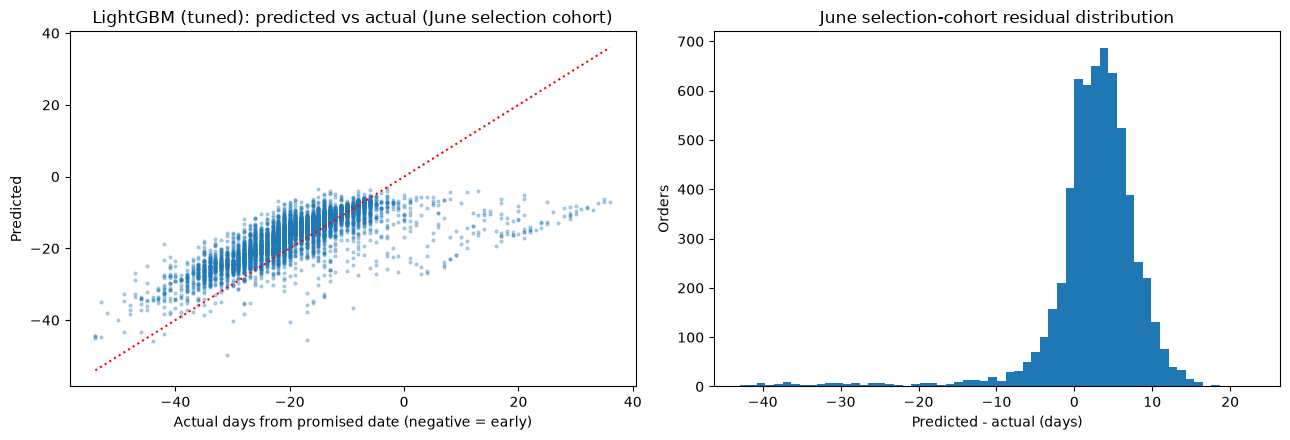

In [22]:
residuals = explanation_rows[['customer_state', 'route_type']].copy()
residuals['actual'] = y_explain.to_numpy()
residuals['predicted'] = selected_june['predicted'].to_numpy()
residuals['error'] = residuals['predicted'] - residuals['actual']
for segment in ['route_type', 'customer_state']:
    table = residuals.groupby(segment).agg(orders=('error', 'size'), actual_mean=('actual', 'mean'),
                                           predicted_mean=('predicted', 'mean'), bias=('error', 'mean'),
                                           mae=('error', lambda e: e.abs().mean()))
    display(table.sort_values('orders', ascending=False).head(12))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(residuals['actual'], residuals['predicted'], s=4, alpha=0.3)
limits = [residuals[['actual', 'predicted']].min().min(), residuals[['actual', 'predicted']].max().max()]
axes[0].plot(limits, limits, color='red', linestyle=':')
axes[0].set(xlabel='Actual days from promised date (negative = early)', ylabel='Predicted',
            title=f'{selected_label}: predicted vs actual (June selection cohort)')
axes[1].hist(residuals['error'], bins=60)
axes[1].set(xlabel='Predicted - actual (days)', ylabel='Orders', title='June selection-cohort residual distribution')
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/08_predicted_vs_actual.png', dpi=200)
plt.show()

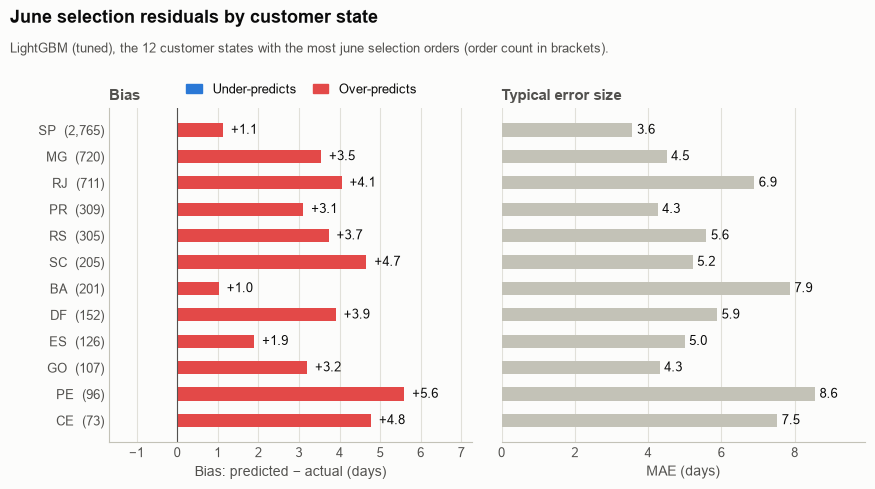

In [23]:
figs.plot_residuals_by_state(residuals, selected_label,
                             save_path=f'{FIGURE_DIR}/07_residuals_by_state.png', cohort_label='June selection')

## Dual framing: development-holdout diagnostic
The best development-holdout regressor flags late orders when predicted days from the promise exceed zero. The comparison below uses the same historical holdout for the regression-derived flag and the two classifiers; it does not select or refit the frozen June model.

In [24]:
# A few orders have a regression target but no late label yet (promised date still ahead)
test_known, train_known = test_df['late_label'].notna(), train_df['late_label'].notna()
print(f'Orders without a known late label (excluded here): training {(~train_known).sum()}, development holdout {(~test_known).sum()}')
cls_train, cls_test = train_df[train_known], test_df[test_known]
test_late = cls_test['late_label'].astype(int)
train_late = cls_train['late_label'].astype(int)
margin = test_predictions[holdout_key][test_known.to_numpy()]  # Predicted days after the promise
dual_rows = {'Regression-derived flag': classification_metrics(test_late, (margin > 0).astype(int), margin)}

def fit_classifier(model, num_cols, scale):
    pipeline = Pipeline([('preprocessor', make_preprocessor(num_cols, CAT_COLS, scale)), ('model', model)])
    pipeline.fit(cls_train[num_cols + CAT_COLS], train_late)
    prob = pipeline.predict_proba(cls_test[num_cols + CAT_COLS])[:, 1]
    return classification_metrics(test_late, (prob >= 0.5).astype(int), prob)

ratio = (train_late == 0).sum() / (train_late == 1).sum()

for label, cols in [('v2 features', NUM_COLS), ('v2 + extra features', REG_NUM_COLS)]:
    dual_rows[f'LightGBM classifier ({label})'] = fit_classifier(
        LGBMClassifier(scale_pos_weight=ratio, random_state=RANDOM_STATE, verbosity=-1), cols, scale=False)
    dual_rows[f'LogisticRegression ({label})'] = fit_classifier(
        LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE), cols, scale=True)

print(f'Development-holdout late rate: {test_late.mean():.2%}')
display(pd.DataFrame(dual_rows).T)


Orders without a known late label (excluded here): training 0, development holdout 1


Development-holdout late rate: 10.06%


,roc_auc,avg_precision,accuracy,precision,recall,f1_score
Regression-derived flag,0.640,0.169,0.899,0.000,0.000,0.000
LightGBM classifier (v2 features),0.600,0.157,0.676,0.139,0.430,0.210
LogisticRegression (v2 features),0.683,0.193,0.768,0.207,0.463,0.286
LightGBM classifier (v2 + extra features),0.684,0.211,0.747,0.205,0.527,0.295
LogisticRegression (v2 + extra features),0.713,0.224,0.731,0.208,0.595,0.308


## Report tables and saved settings

,Model,Variant,CV MAE,Holdout MAE,June MAE,June RMSE,June R²,June selected
0,Decision Tree,default,8.816,8.269,7.686,11.420,-0.383,False
1,Decision Tree,tuned,5.750,5.883,7.547,9.127,0.117,False
2,Dummy (median),reference,6.441,6.733,9.248,11.846,-0.488,False
3,LightGBM,default,5.653,5.569,6.181,7.850,0.347,False
4,LightGBM,tuned,5.537,5.394,4.846,6.911,0.494,True
5,Linear Regression,default,6.149,5.585,6.549,8.120,0.301,False
6,Olist promise,reference,12.810,11.867,19.307,20.895,-3.630,False
7,Random Forest,default,5.933,5.729,7.027,8.590,0.218,False
8,Random Forest,tuned,5.616,5.669,6.350,8.018,0.318,False
9,Ridge,default,6.159,5.602,6.544,8.115,0.302,False


,Model,CV MAE gain,Holdout MAE gain,June MAE gain
0,Ridge,0.100,-0.026,-0.144
1,Decision Tree,3.066,2.386,0.139
2,Random Forest,0.317,0.060,0.678
3,LightGBM,0.117,0.175,1.336


,Selection sample,Model,Variant,MAE (days)
0,Development holdout,LightGBM,tuned,5.394
1,June orders,LightGBM,tuned,4.846


,Month,Scored,Evaluated,MAE (days),RMSE (days),R²
0,2018-06,6164,6164,4.846,6.911,0.494
1,2018-07,6176,6159,4.612,7.616,0.314
2,2018-08,6620,6612,4.591,7.471,0.414


{'html': PosixPath('results/report_tables/regression_report.html'), 'latex': PosixPath('results/report_tables/regression_report.tex')}


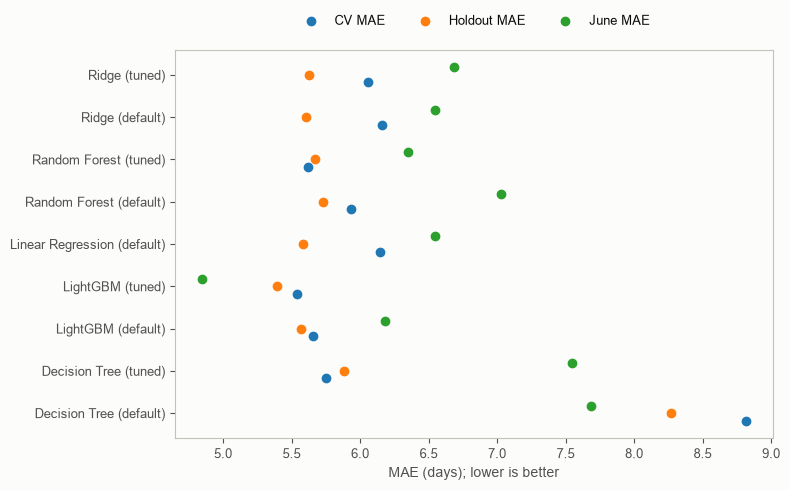

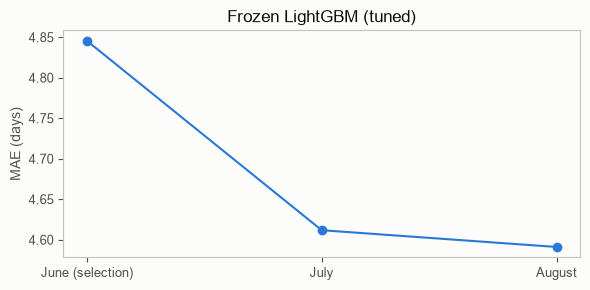

In [25]:
# Compact report tables: June selection and frozen later-month performance.
scores = cv_results[['cv_mae_mean']].join(holdout_results[['mae']].rename(columns={'mae': 'holdout_mae'}))
scores = scores.join(june_metrics[['mae', 'rmse', 'r2']]).rename_axis(['Model', 'Variant']).reset_index()
scores = scores.rename(columns={'cv_mae_mean': 'CV MAE', 'holdout_mae': 'Holdout MAE',
                                'mae': 'June MAE', 'rmse': 'June RMSE', 'r2': 'June R²'})
scores['June selected'] = [(m, v) == june_key for m, v in zip(scores['Model'], scores['Variant'])]
gains = []

for name in SEARCH_SPACES:
    pair = scores[scores['Model'].eq(name)].set_index('Variant')
    gains.append({'Model': name, **{stage + ' gain': pair.loc['default', stage] - pair.loc['tuned', stage]
                                   for stage in ['CV MAE', 'Holdout MAE', 'June MAE']}})

gains = pd.DataFrame(gains)
settings = pd.DataFrame([{'Model': name, 'CV-selected parameters': json.dumps(params, sort_keys=True)}
                         for name, params in best_params.items()])

selection = pd.DataFrame([
    {'Selection sample': 'Development holdout', 'Model': holdout_key[0], 'Variant': holdout_key[1],
     'MAE (days)': holdout_results.loc[holdout_key, 'mae']},
    {'Selection sample': 'June orders', 'Model': june_key[0], 'Variant': june_key[1],
     'MAE (days)': june_metrics.loc[june_key, 'mae']},
])

note = ('June orders select the frozen model by lowest MAE; references are excluded from selection. '
        'June performance is a selection result, not an independent final-test estimate.')

report_tables = [
    dict(title='Regression development and June model selection', frame=scores,
         note=note, prose='All default and tuned candidates are refitted on identical pre-June history before scoring June orders.'),
    dict(title='Regression tuning gains', frame=gains,
         note='Gain = default MAE minus tuned MAE, in days. Positive values favor tuning.',
         prose='The same candidate pairs are compared during CV, on the development holdout, and on pooled June orders.'),
    dict(title='Regression selection decisions', frame=selection,
         note='The two decisions use different samples; the June-selected fitted model is retained unchanged.',
         prose='The historical holdout winner is recorded separately from the frozen model selected using June outcomes.'),
    dict(title='Frozen regression model: June–August', frame=frozen_metrics,
         note=('No retraining or retuning for July/August. June is the selection cohort. Complete June outcomes '
               'are fully mature by 15 August, so early later-month predictions form a retrospective stability check. '
               'The latest recorded delivery is an unverified observation-end proxy.'),
         prose=f'The same fitted {selected_label} pipeline scores all three cohorts; every reported outcome uses the 45-day horizon.'),
]

for table in report_tables:
    display(table['frame'])

report_paths = export_report_tables(report_tables, REPORT_DIR, 'regression_report')
scores.to_csv(REPORT_DIR / 'regression_june_model_comparison.csv', index=False)
gains.to_csv(REPORT_DIR / 'regression_june_tuning_gains.csv', index=False)
selection.to_csv(REPORT_DIR / 'regression_june_selections.csv', index=False)
settings.to_csv(REPORT_DIR / 'regression_june_cv_settings.csv', index=False)
frozen_metrics.to_csv(REPORT_DIR / 'regression_frozen_monthly_metrics.csv', index=False)
june_predictions.to_csv(REPORT_DIR / 'regression_june_predictions.csv', index=False)
frozen_predictions.to_csv(REPORT_DIR / 'regression_frozen_predictions.csv', index=False)
importance.to_csv(REPORT_DIR / 'regression_june_feature_importance.csv', index=False)

regression_output = {
    'run_date': RUN_DATE, 'waiting_period_days': WAITING_PERIOD, 'history_days': PXD,
    'test_days': TEST_DAYS, 'cv_folds': N_CV_FOLDS, 'cv_gap_days': WAITING_PERIOD,
    'cv_validation_days': CV_VALIDATION_DAYS, 'scoring': 'neg_mean_absolute_error',
    'development_holdout': {'start': str(test_df['order_approved_dt'].min().date()),
                            'end': str(test_df['order_approved_dt'].max().date()),
                            'best_model': holdout_key[0], 'variant': holdout_key[1],
                            'mae': holdout_results.loc[holdout_key, 'mae']},
    'june_selected': {'model': june_key[0], 'variant': june_key[1],
                      'mae': june_metrics.loc[june_key, 'mae'],
                      'refit_orders': len(reg_df), 'selection_sample': 'June 2018 orders'},
    'later_months': 'Frozen June fitted pipeline; no retraining; retrospective until June labels mature',
    'models': {name: {'family': MODEL_FAMILY[name], 'best_params': best_params.get(name, {}),
                      'cv_mae_default': cv_results.loc[(name, 'default'), 'cv_mae_mean'],
                      'cv_mae_tuned': cv_results.loc[(name, 'tuned'), 'cv_mae_mean'] if name in tuned_models else None}
               for name in default_models},
}

Path('results/regression_tuning.json').write_text(json.dumps(regression_output, indent=2))
print(report_paths)

# Figures distinguish development scores from June selection and subsequent drift checks.

with plt.rc_context(figs.STYLE):
    plot_rows = scores[scores['Variant'].ne('reference')]
    fig, ax = plt.subplots(figsize=(8, 5))
    for position, column in enumerate(['CV MAE', 'Holdout MAE', 'June MAE']):
        ax.scatter(plot_rows[column], np.arange(len(plot_rows)) + (position - 1) * .18, label=column)
    ax.set_yticks(range(len(plot_rows)), [f'{r.Model} ({r.Variant})' for r in plot_rows.itertuples()])
    ax.set_xlabel('MAE (days); lower is better')
    ax.legend(loc='upper center', bbox_to_anchor=(.5, 1.12), ncol=3)
    fig.tight_layout()
    fig.savefig(f'{FIGURE_DIR}/04_mae_cv_holdout_backtest.png', dpi=200)
    plt.show()
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(['June (selection)', 'July', 'August'], frozen_metrics['MAE (days)'], marker='o', color=figs.BLUE)
    ax.set_ylabel('MAE (days)')
    ax.set_title(f'Frozen {selected_label}')
    fig.tight_layout()
    fig.savefig(f'{FIGURE_DIR}/05_monthly_backtest_mae.png', dpi=200)
    plt.show()


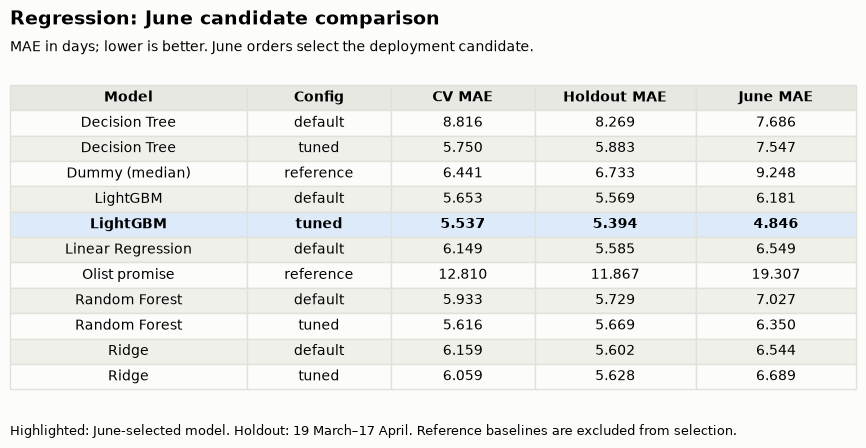

In [26]:
# Rebuild the compact June candidate figure from the saved comparison table; no fitting.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.read_csv('results/report_tables/regression_june_model_comparison.csv')
columns = ['Model', 'Variant', 'CV MAE', 'Holdout MAE', 'June MAE']
compact = comparison[columns].copy().rename(columns={'Variant': 'Config'})

for column in ['CV MAE', 'Holdout MAE', 'June MAE']:
    compact[column] = compact[column].map(lambda value: f'{value:.3f}')

fig, ax = plt.subplots(figsize=(9.2, 4.7))
fig.patch.set_facecolor('#fcfcfb')
ax.axis('off')
fig.text(.04, .95, 'Regression: June candidate comparison', fontsize=14, weight='bold', va='top')
fig.text(.04, .885, 'MAE in days; lower is better. June orders select the deployment candidate.', fontsize=10, va='top')
table = ax.table(cellText=compact.values, colLabels=compact.columns, cellLoc='center',
                 colWidths=[.28, .17, .17, .19, .19], bbox=[0, .08, 1, .83])
table.auto_set_font_size(False)
table.set_fontsize(10)

for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor('#e1e0d9')
    if row == 0:
        cell.set_facecolor('#e8e8e3')
        cell.set_text_props(weight='bold')
    elif bool(comparison.iloc[row - 1]['June selected']):
        cell.set_facecolor('#dceafa')
        cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor('#fcfcfb' if row % 2 else '#f0f0eb')

fig.text(.04, .045, 'Highlighted: June-selected model. Holdout: 19 March–17 April. Reference baselines are excluded from selection.', fontsize=9)
fig.subplots_adjust(left=.04, right=.96, top=.86, bottom=.08)
fig.savefig('results/figures/10_june_regression_candidates.png', dpi=200)
plt.show()
